# LangGraph 入门：用图搭一个文本分析流水线

LangGraph 是一个用“图（graph）”来组织应用流程的框架：

- **node（节点）**：一个函数或一个计算步骤
- **edge（边）**：节点之间的流转关系（可以是固定顺序，也可以是条件分支）

## 关键特性
- State 管理
- 灵活路由（分支/循环）
- 持久化（可选）
- 可视化（把 graph 画出来）


## 教程概览：文本分析流水线

我们用一个“多步文本分析流水线”来演示 LangGraph 的用法，输入是一段文本，经过三步处理：

1. **文本分类**：把文本分到一个预定义类别（News/Blog/Research/Other）
2. **实体抽取**：抽取 Person / Organization / Location 等实体
3. **文本摘要**：生成一句话摘要

这个例子重点不在 NLP 任务本身，而在于：你会看到如何把一个流程拆成多个 node，并用 graph 把它们组织起来。

### 导入依赖
导入本节所需的模块与类。

In [1]:
import os
from typing import List, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import HumanMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph

### 加载环境变量
这里我们只做一件事：加载上一级目录的 `.env`，让模型初始化时能直接读到必要的环境变量。

In [2]:
load_dotenv("../.env")

True

## 构建文本处理流水线

### 1) 定义 State + 初始化模型
State 是这个 graph 在运行时携带的数据结构：每个 node 都会读它、并返回一个增量更新。

In [3]:
class State(TypedDict):
    text: str
    classification: str
    entities: List[str]
    summary: str


llm = ChatOpenAI(
    model="deepseek-v4-flash-0731",
    api_key=os.environ.get("DASHSCOPE_API_KEY"),
    base_url=os.environ.get("DASHSCOPE_BASE_URL"),
    temperature=0,
)

### 2) 定义 node 函数
我们为三步处理分别定义三个 node。每个 node 都接收 `state`，并返回一个 dict，表示对 state 的增量更新。

In [4]:
def classification_node(state: State):
    """把文本分类到 News / Blog / Research / Other。"""
    prompt = PromptTemplate(
        input_variables=["text"],
        template=(
            "Classify the following text into one of the categories: News, Blog, Research, or Other.\n\n"
            "Text:{text}\n\n"
            "Category:"
        ),
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    classification = llm.invoke([message]).content.strip()
    return {"classification": classification}


def entity_extraction_node(state: State):
    """抽取实体（Person / Organization / Location），以逗号分隔输出。"""
    prompt = PromptTemplate(
        input_variables=["text"],
        template=(
            "Extract all the entities (Person, Organization, Location) from the following text. "
            "Provide the result as a comma-separated list.\n\n"
            "Text:{text}\n\n"
            "Entities:"
        ),
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    entities = llm.invoke([message]).content.strip().split(", ")
    return {"entities": entities}


def summarization_node(state: State):
    """把文本总结成一句话摘要。"""
    prompt = PromptTemplate(
        input_variables=["text"],
        template=(
            "Summarize the following text in one short sentence.\n\n"
            "Text:{text}\n\n"
            "Summary:"
        ),
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    summary = llm.invoke([message]).content.strip()
    return {"summary": summary}

### 3) 组装 StateGraph
我们把三个 node 加进图里，并用 edge 指定执行顺序：分类 → 实体抽取 → 摘要 → 结束。

In [5]:
workflow = StateGraph(State)

# 添加节点
workflow.add_node("classification_node", classification_node)
workflow.add_node("entity_extraction", entity_extraction_node)
workflow.add_node("summarization", summarization_node)

# 添加边（固定顺序）
workflow.set_entry_point("classification_node")
workflow.add_edge("classification_node", "entity_extraction")
workflow.add_edge("entity_extraction", "summarization")
workflow.add_edge("summarization", END)

# 编译成可运行 app
app = workflow.compile()

## 可视化：把 workflow 画出来
这段会用 Mermaid 把 graph 渲染成图片（便于你直观看到节点与边）。

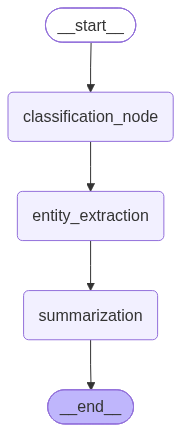

In [6]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## 测试流水线
把一段示例文本送入 graph，查看输出的分类、实体、摘要。

In [7]:
sample_text = """
OpenAI has announced the GPT-4 model, which is a large multimodal model that exhibits human-level performance on various professional benchmarks. It is developed to improve the alignment and safety of AI systems.
additionally, the model is designed to be more efficient and scalable than its predecessor, GPT-3. The GPT-4 model is expected to be released in the coming months and will be available to the public for research and development purposes.
"""

state_input = {"text": sample_text}
result = app.invoke(state_input)

print("Classification:", result["classification"])
print("\nEntities:", result["entities"])
print("\nSummary:", result["summary"])

Classification: Category: News

Entities: ['OpenAI']

Summary: OpenAI announced GPT-4, a more efficient and safer multimodal model with human-level performance, set to be released publicly soon.


## 总结

你已经完成了一个最小 LangGraph 应用：

- 用 `TypedDict` 定义 State
- 把每一步写成一个 node（函数）
- 用 edge 把流程串成一个 graph
- `compile()` 得到可运行的 app

后面当你需要分支、循环、工具调用、记忆（checkpointer）时，也是在这个基础上逐步加能力。

## 检查理解（含答案）

1) **为什么 node 要返回 dict？**
- 答：node 的返回值就是“对 State 的增量更新”，LangGraph 会把这些更新合并回 state，传给后续节点。

2) **edge 的意义是什么？**
- 答：edge 定义了节点执行的流转关系。这个例子是固定顺序；更复杂的情况可以是条件边（分支）或循环。

3) **`compile()` 做了什么？**
- 答：把你定义的 StateGraph 固化成一个可运行的 app（支持 `invoke`/`stream` 等执行方式）。